In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("multimodal_sports_injury_dataset.csv")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (15420, 29)


,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
0,1,NaN,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,...,5.678475,79.106564,548.417962,45.028687,0,1,Basketball,Female,18,25.105748
1,1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,...,NaN,116.954654,538.043815,42.254717,2,2,Basketball,Female,18,25.105748
2,1,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,...,6.643242,96.354742,647.784339,61.870056,0,3,Basketball,Female,18,25.105748
3,1,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,...,6.194427,97.619130,336.553431,50.268845,0,4,Basketball,Female,18,25.105748
4,1,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,...,5.835804,83.155527,496.076352,29.233575,2,5,Basketball,Female,18,25.105748


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   athlete_id             15420 non-null  int64  
 1   heart_rate             15066 non-null  float64
 2   body_temperature       15420 non-null  float64
 3   hydration_level        15035 non-null  float64
 4   sleep_quality          14927 non-null  float64
 5   recovery_score         15420 non-null  float64
 6   stress_level           15420 non-null  float64
 7   muscle_activity        14850 non-null  float64
 8   joint_angles           15420 non-null  float64
 9   gait_speed             14989 non-null  float64
 10  cadence                15420 non-null  float64
 11  step_count             15420 non-null  int64  
 12  jump_height            15420 non-null  float64
 13  ground_reaction_force  15420 non-null  float64
 14  range_of_motion        15420 non-null  float64
 15  am

In [4]:
df.isnull().sum()

athlete_id                 0
heart_rate               354
body_temperature           0
hydration_level          385
sleep_quality            493
recovery_score             0
stress_level               0
muscle_activity          570
joint_angles               0
gait_speed               431
cadence                    0
step_count                 0
jump_height                0
ground_reaction_force      0
range_of_motion            0
ambient_temperature        0
humidity                   0
altitude                   0
playing_surface            0
training_intensity       632
training_duration          0
training_load              0
fatigue_index              0
injury_occurred            0
session_id                 0
sport_type                 0
gender                     0
age                        0
bmi                        0
dtype: int64

In [5]:
# Fill numerical columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# For categorical
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/var/folders/s2/bvqbtg2j12511s6h71zdywmw0000gn/T/ipykernel_10998/1158515747.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.describe()

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,altitude,playing_surface,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,age,bmi
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,...,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,78.547601,72.688277,37.106443,78.036991,5.817429,55.202220,0.422916,247.724105,112.464607,1.864699,...,297.357416,2.019326,6.399174,87.790419,670.534269,59.698315,0.510117,49.926719,23.953567,23.138679
std,45.070131,17.553946,0.594843,11.699506,1.785357,17.326338,0.173425,124.561779,30.367148,0.595426,...,212.351977,1.409120,1.695038,27.628191,328.288466,25.196238,0.741662,28.540223,3.883533,2.301192
min,1.000000,40.000000,35.800000,45.000000,1.155807,8.902584,0.100000,10.000000,45.000000,0.800000,...,0.000000,0.000000,2.000000,30.000000,150.000000,15.000000,0.000000,1.000000,18.000000,18.500000
25%,39.000000,60.416589,36.698612,70.134284,4.559585,42.321722,0.300472,163.165706,91.437246,1.446922,...,127.750679,1.000000,5.273661,68.768634,426.148857,41.717110,0.000000,25.000000,21.000000,21.609635
50%,79.000000,72.688277,37.107090,78.036991,5.817429,54.421403,0.421168,247.724105,112.548535,1.864699,...,284.172663,2.000000,6.399174,87.835380,645.225337,57.340187,0.000000,50.000000,24.000000,22.988013
75%,118.000000,84.475495,37.512165,86.245543,7.024223,67.375690,0.543678,330.192565,133.960070,2.263856,...,442.388486,3.000000,7.528724,106.696365,879.607967,75.186924,1.000000,75.000000,27.000000,24.817666
max,156.000000,159.270125,39.200000,100.000000,10.000000,98.000000,0.950000,722.542819,175.000000,3.500000,...,1200.000000,4.000000,10.000000,180.000000,2632.637547,270.193219,2.000000,101.000000,34.000000,28.300000


In [8]:
df.columns

Index(['athlete_id', 'heart_rate', 'body_temperature', 'hydration_level',
       'sleep_quality', 'recovery_score', 'stress_level', 'muscle_activity',
       'joint_angles', 'gait_speed', 'cadence', 'step_count', 'jump_height',
       'ground_reaction_force', 'range_of_motion', 'ambient_temperature',
       'humidity', 'altitude', 'playing_surface', 'training_intensity',
       'training_duration', 'training_load', 'fatigue_index',
       'injury_occurred', 'session_id', 'sport_type', 'gender', 'age', 'bmi'],
      dtype='object')

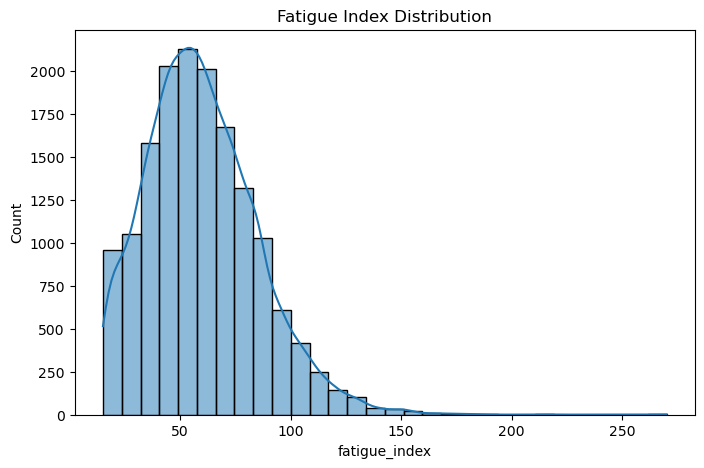

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['fatigue_index'], kde=True, bins=30)
plt.title("Fatigue Index Distribution")
plt.show()

In [10]:
import plotly.figure_factory as ff

# Prepare data
data = [df['fatigue_index'].dropna()]

# Create distribution plot (Histogram + KDE)
fig = ff.create_distplot(
    data,
    group_labels=['Fatigue Index'],
    bin_size=5   # adjust based on your data scale
)

fig.update_layout(
    title="Fatigue Index Distribution",
    xaxis_title="Fatigue Index",
    yaxis_title="Density"
)

fig.show()

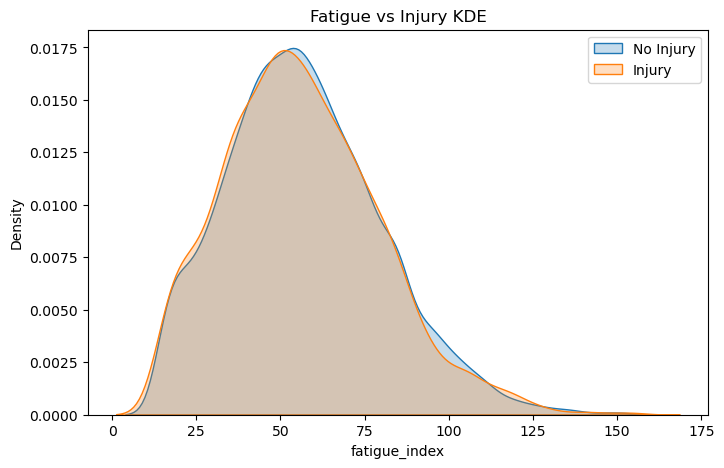

In [11]:
plt.figure(figsize=(8,5))

sns.kdeplot(df[df['injury_occurred']==0]['fatigue_index'], label='No Injury', fill=True)
sns.kdeplot(df[df['injury_occurred']==1]['fatigue_index'], label='Injury', fill=True)

plt.title("Fatigue vs Injury KDE")
plt.legend()
plt.show()

In [12]:
import plotly.figure_factory as ff

# Separate data
no_injury = df[df['injury_occurred'] == 0]['fatigue_index'].dropna()
injury = df[df['injury_occurred'] == 1]['fatigue_index'].dropna()

# Create distribution plot (KDE + histogram optional)
fig = ff.create_distplot(
    [no_injury, injury],
    group_labels=['No Injury', 'Injury'],
    show_hist=False,   # Only KDE (like your seaborn plot)
    show_rug=False
)

fig.update_layout(
    title="Fatigue vs Injury (KDE Comparison)",
    xaxis_title="Fatigue Index",
    yaxis_title="Density"
)

fig.show()

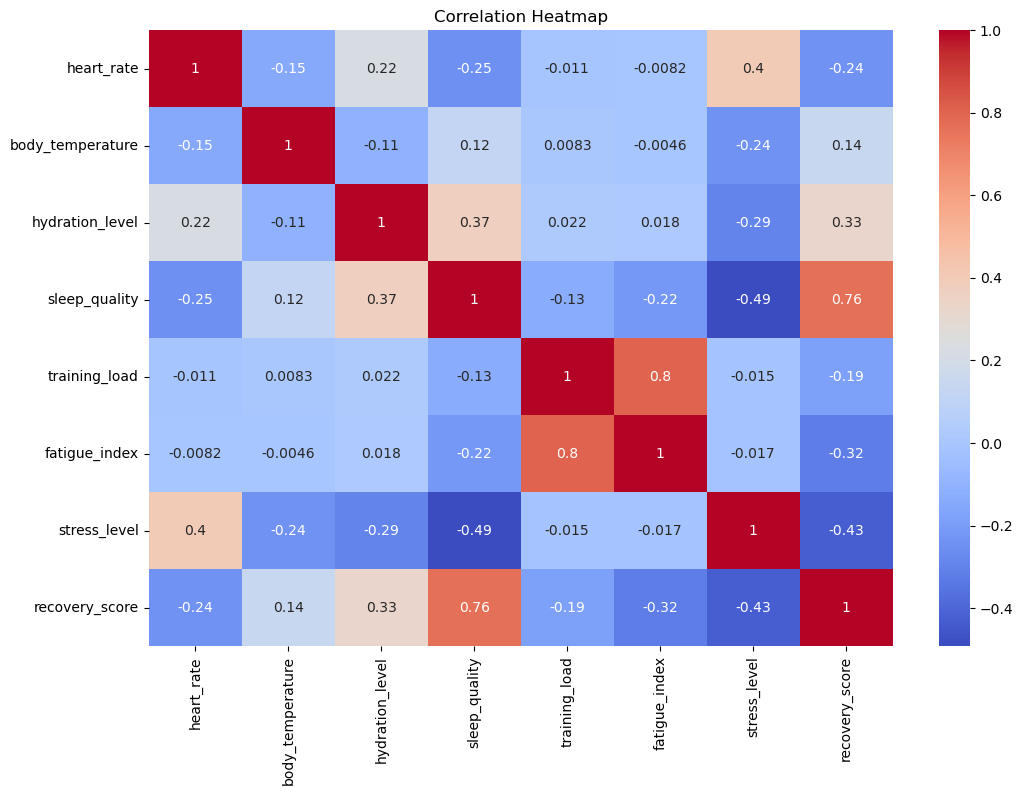

In [13]:
plt.figure(figsize=(12,8))

corr_cols = ['heart_rate','body_temperature','hydration_level','sleep_quality',
             'training_load','fatigue_index','stress_level','recovery_score']

sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

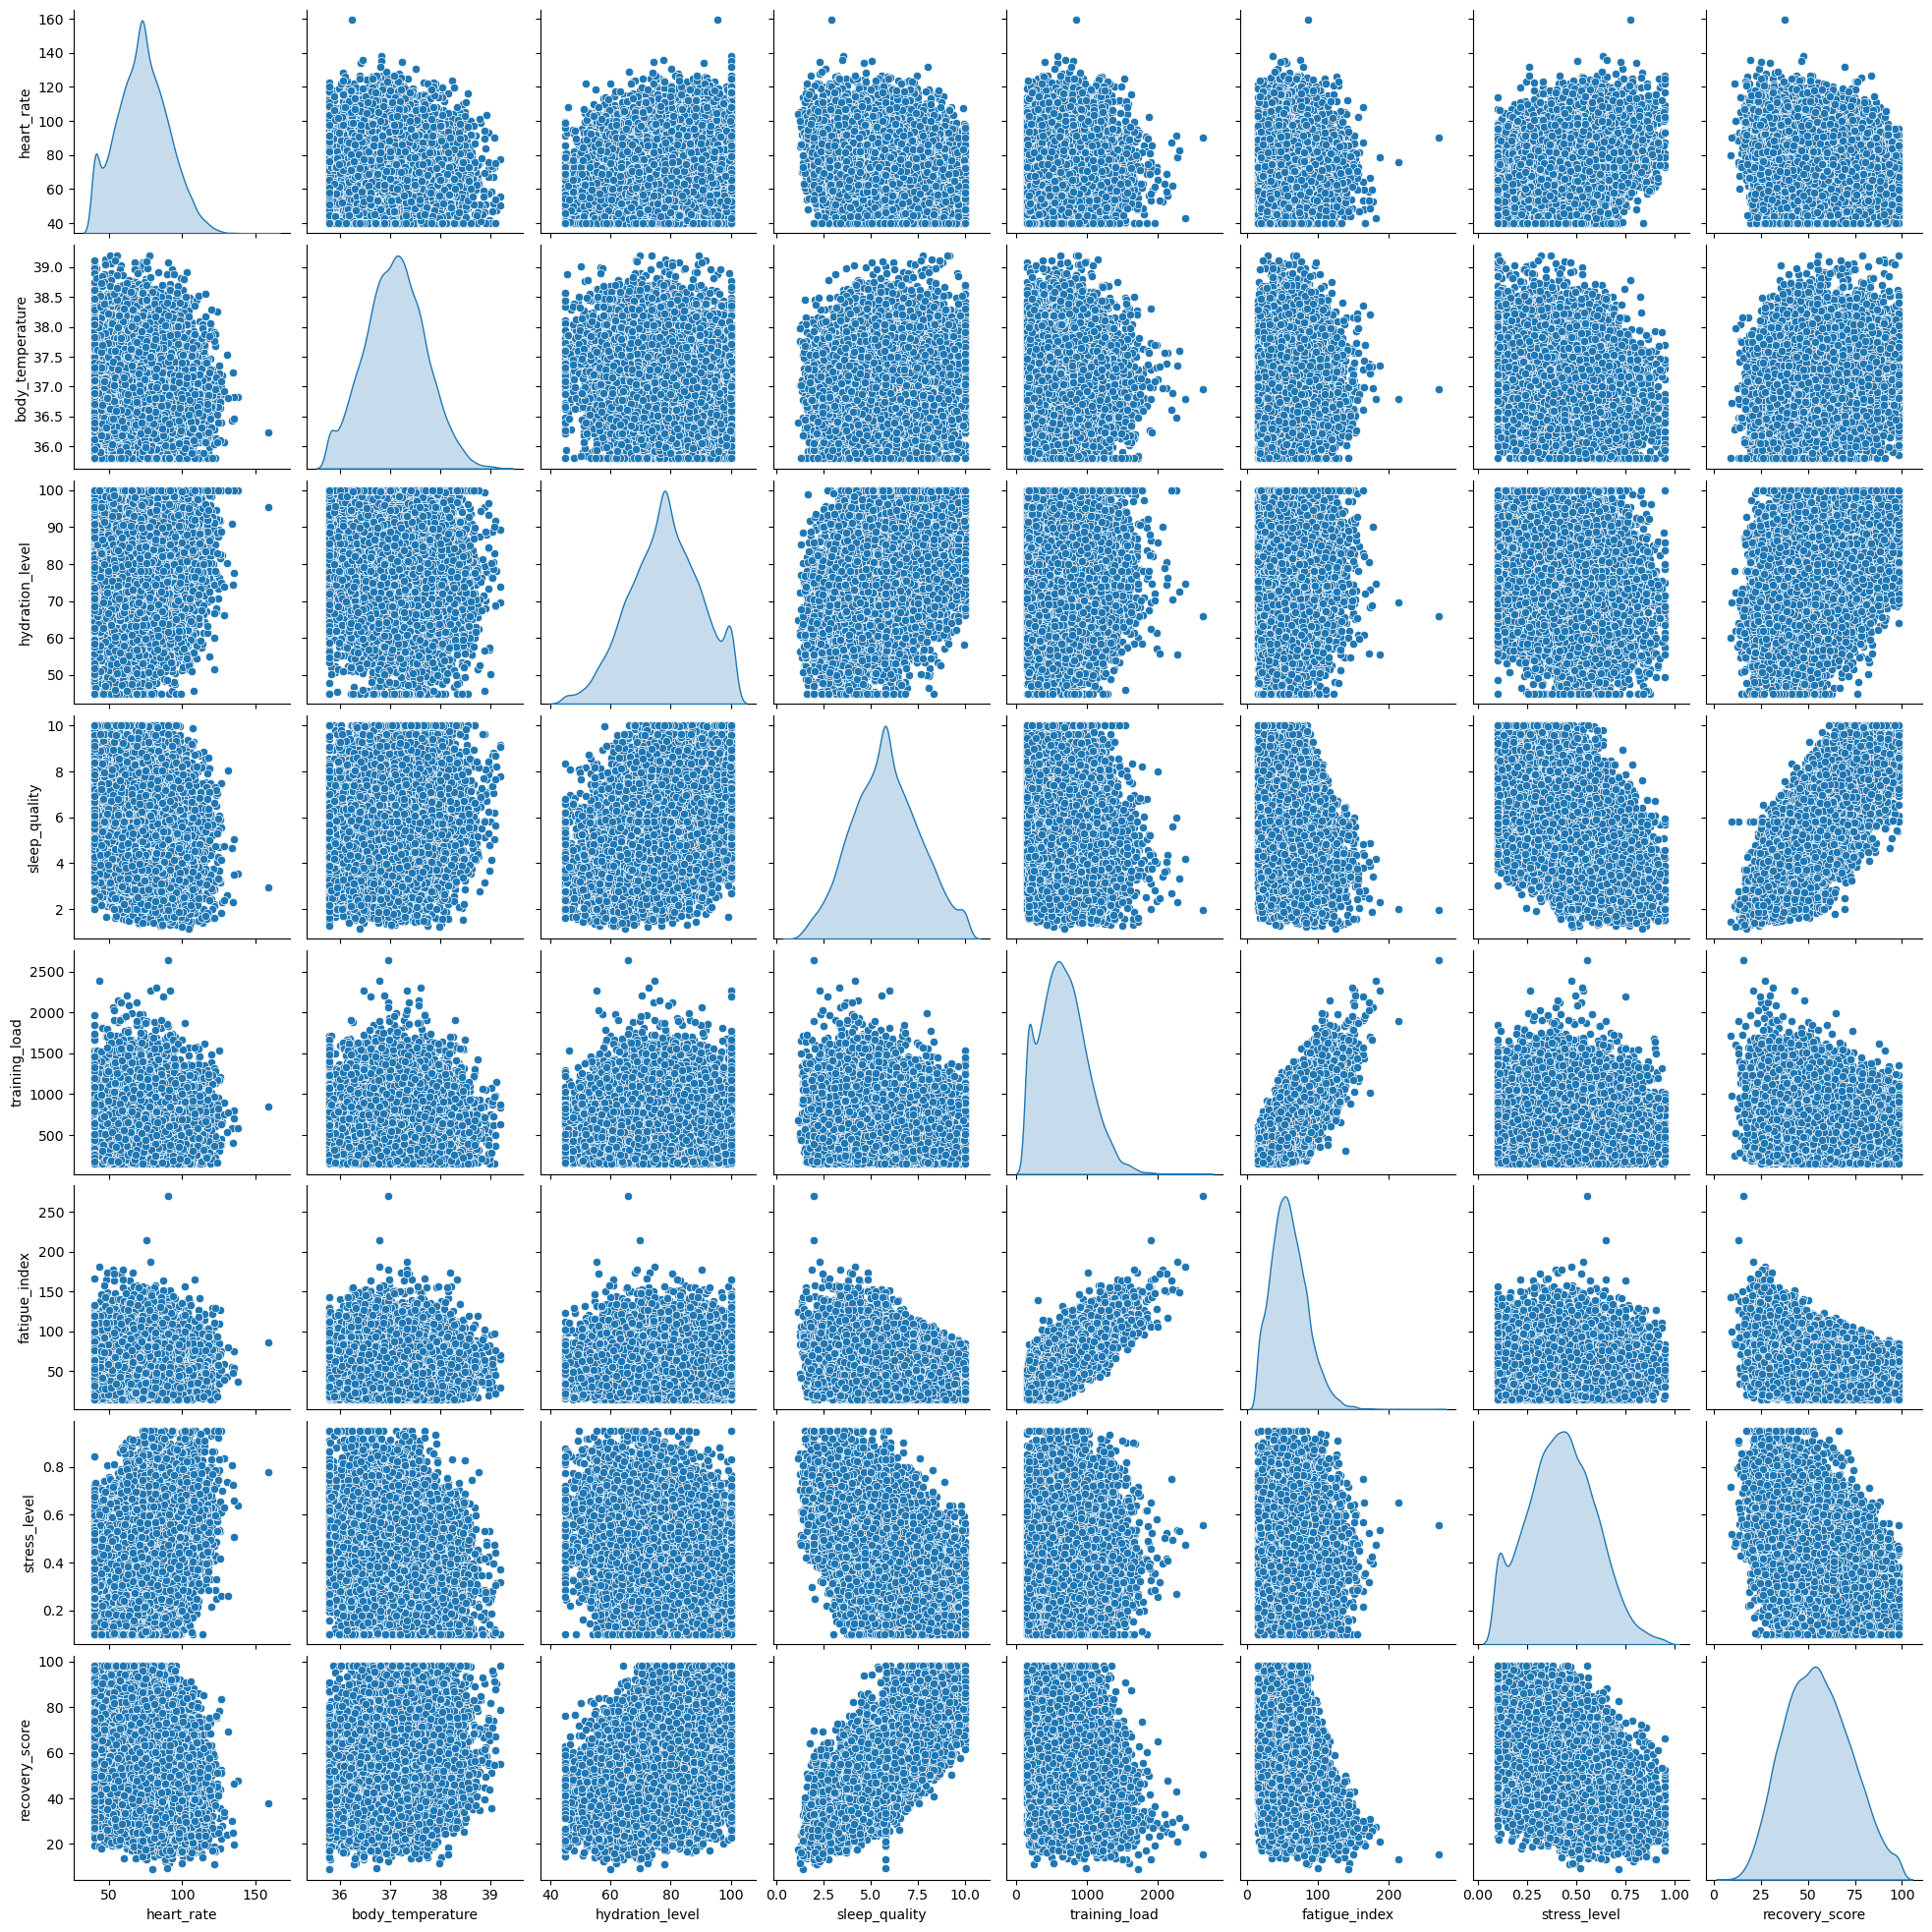

In [14]:
sns.pairplot(df[corr_cols], diag_kind='kde')
plt.show()

In [15]:
import plotly.express as px

# Then use it to create your histogram
fig = px.histogram(df, x="fatigue_index", nbins=40,
                   marginal="box",
                   title="Fatigue Index Distribution")

fig.show()

In [16]:
fig = px.scatter(df, x="training_load", y="fatigue_index",
                 color="injury_occurred",
                 trendline="ols",
                 title="Training Load vs Fatigue")

fig.show()

In [17]:
fig = px.scatter_3d(df,
                    x='heart_rate',
                    y='training_load',
                    z='fatigue_index',
                    color='injury_occurred',
                    title="3D Fatigue Visualization")

fig.show()

In [18]:
fig = px.parallel_coordinates(
    df,
    color="fatigue_index",
    dimensions=['heart_rate','training_load','sleep_quality',
                'hydration_level','stress_level'],
    title="Multi-feature Fatigue Analysis"
)

fig.show()

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("multimodal_sports_injury_dataset.csv")

In [21]:
df

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
0,1,NaN,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,...,5.678475,79.106564,548.417962,45.028687,0,1,Basketball,Female,18,25.105748
1,1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,...,NaN,116.954654,538.043815,42.254717,2,2,Basketball,Female,18,25.105748
2,1,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,...,6.643242,96.354742,647.784339,61.870056,0,3,Basketball,Female,18,25.105748
3,1,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,...,6.194427,97.619130,336.553431,50.268845,0,4,Basketball,Female,18,25.105748
4,1,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,...,5.835804,83.155527,496.076352,29.233575,2,5,Basketball,Female,18,25.105748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,84,69.956860,37.214621,69.544088,4.418336,38.957484,0.239706,NaN,127.835085,NaN,...,7.038863,63.341808,627.752431,52.845054,0,100,Basketball,Female,26,20.145185
15416,18,70.785554,36.927019,84.422453,3.976723,34.893546,0.472006,263.783492,128.887289,NaN,...,5.504547,81.735077,1001.613854,67.373233,2,100,Track,Female,24,21.309957
15417,141,108.757968,36.875496,76.679104,4.552625,39.487996,0.628583,333.898593,157.497212,2.176849,...,7.794103,106.064377,767.130093,76.089216,1,100,Basketball,Male,23,28.098897
15418,113,65.489580,37.343535,60.761053,3.877293,39.956892,0.664920,320.438215,123.040641,2.342617,...,5.703675,108.543899,793.033403,76.804070,0,99,Track,Female,34,22.719505


In [22]:
# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [23]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

/var/folders/s2/bvqbtg2j12511s6h71zdywmw0000gn/T/ipykernel_10998/3943753284.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [24]:
threshold = df['fatigue_index'].quantile(0.75)
df['fatigue_label'] = (df['fatigue_index'] > threshold).astype(int)

In [25]:
features = [
    'heart_rate','body_temperature','hydration_level','sleep_quality',
    'recovery_score','stress_level','training_load','training_duration',
    'muscle_activity','step_count','jump_height','ground_reaction_force'
]
X = df[features]
y = df['fatigue_label']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


input_df = pd.DataFrame({
    'feature1': [1, 2, 3, 4, 5],
    'feature2': [10, 20, 30, 40, 50],
    'feature3': [0.1, 0.2, 0.3, 0.4, 0.5]
})


scaler = StandardScaler()
scaler.fit(input_df.astype(float))  # Fit the scaler on your data


input_scaled = scaler.transform(input_df.astype(float))

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [30]:
LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')

LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')

In [31]:
RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42
)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=12,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [32]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, accuracy, precision, recall, f1])
    
    print(f"\n{name}")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8745136186770428
Precision: 0.7817589576547231
Recall: 0.654843110504775
F1 Score: 0.7126948775055679
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2351
           1       0.78      0.65      0.71       733

    accuracy                           0.87      3084
   macro avg       0.84      0.80      0.82      3084
weighted avg       0.87      0.87      0.87      3084


Decision Tree
Accuracy: 0.8138780804150454
Precision: 0.6017925736235595
Recall: 0.6412005457025921
F1 Score: 0.6208718626155878
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2351
           1       0.60      0.64      0.62       733

    accuracy                           0.81      3084
   macro avg       0.74      0.75      0.75      3084
weighted avg       0.82      0.81      0.82      3084


Random Forest
Accuracy: 0.8680285343709468
Precision: 0.7680921052631579
Recall:

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning:

[17:43:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




In [33]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by F1 Score (best on top)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

# Display table
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.874514   0.781759  0.654843  0.712695
2        Random Forest  0.868029   0.768092  0.637108  0.696495
3              XGBoost  0.860571   0.740859  0.635744  0.684288
1        Decision Tree  0.818418   0.610191  0.653479  0.631094


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning:

[17:43:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




In [34]:
import plotly.express as px

fig = px.bar(
    results_df,
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    barmode="group",
    title="Model Performance Comparison"
)

fig.show()

In [35]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.874514   0.781759  0.654843  0.712695
1        Decision Tree  0.818418   0.610191  0.653479  0.631094
2        Random Forest  0.868029   0.768092  0.637108  0.696495
3              XGBoost  0.860571   0.740859  0.635744  0.684288


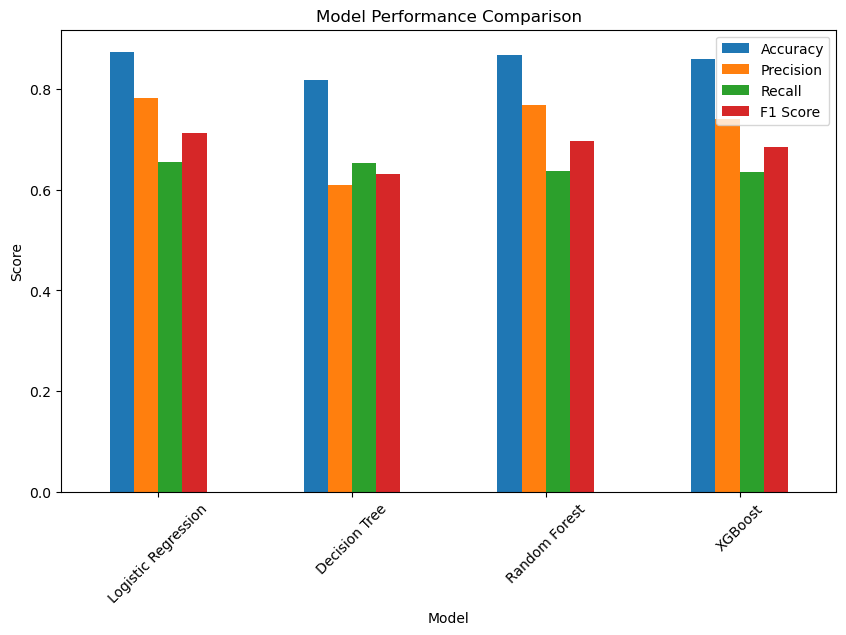

In [36]:
results_df.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [37]:
best_model_name = results_df.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [38]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

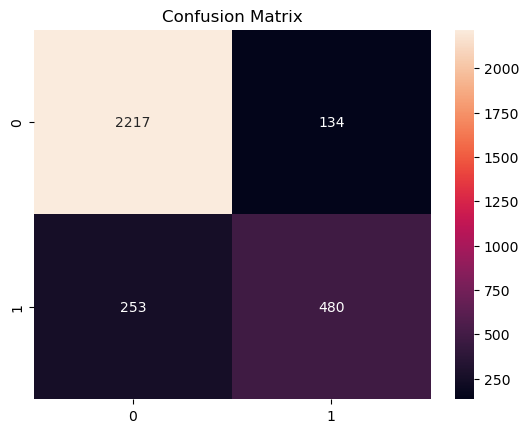

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Multiple machine learning models including Logistic Regression, Decision Tree, Random Forest, and XGBoost were evaluated. Based on accuracy and F1-score, the best-performing model was selected, as it provided the most balanced performance in predicting fatigue levels.

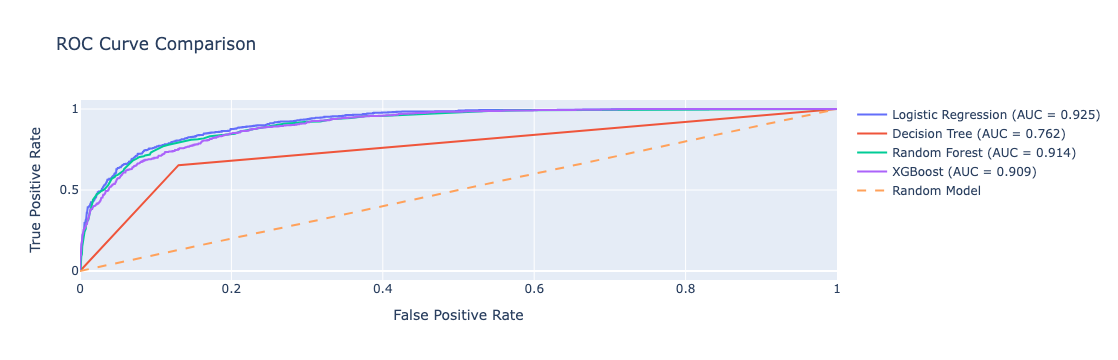

In [40]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go

fig = go.Figure()

for name, model in models.items():
    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    fig.add_trace(go.Scatter(
        x=fpr,
        y=tpr,
        mode='lines',
        name=f"{name} (AUC = {roc_auc:.3f})"
    ))

# Diagonal line
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    line=dict(dash='dash'),
    name='Random Model'
))

fig.update_layout(
    title="ROC Curve Comparison",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate"
)

fig.show()

ROC curve and AUC were used to evaluate model performance across different classification thresholds, providing a more robust comparison beyond accuracy.”

In [41]:
import pickle

pickle.dump(best_model, open("fatigue_model.pkl", "wb"))

In [42]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


# Create the models
rf_model = RandomForestClassifier()
lr_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
xgb_model = XGBClassifier()

pickle.dump(rf_model, open("rf_model.pkl", "wb"))
pickle.dump(lr_model, open("lr_model.pkl", "wb"))
pickle.dump(dt_model, open("dt_model.pkl", "wb"))
pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))

In [43]:
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

In [44]:
df['fatigue_label'].value_counts()

fatigue_label
0    11565
1     3855
Name: count, dtype: int64